# GenAI Text-to-Image Experiments

Notebook for understanding and testing the same local inference pipeline used by the Streamlit application.

## Cell 1 — Imports

In [12]:
# WHY: Verify that the notebook is using our CUDA-enabled project environment.

import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB",
    )

PyTorch: 2.14.0+cu126
CUDA: True
CUDA version: 12.6
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM: 6.0 GB


# WHY: Use a local drive cache on Windows when available.
# The project remains portable for GitHub and deployment.

In [13]:
## Cell 2 — Configure Hugging Face cache
# WHY: Use a local D: drive cache on Windows when available.
# The project remains portable for GitHub and deployment.

import os

if os.name == "nt" and os.path.exists(r"D:\huggingface-cache"):
    os.environ["HF_HOME"] = r"D:\huggingface-cache"
    os.environ["HF_HUB_CACHE"] = r"D:\huggingface-cache\hub"

print("HF_HOME:", os.environ.get("HF_HOME", "Default"))
print("HF_HUB_CACHE:", os.environ.get("HF_HUB_CACHE", "Default"))

HF_HOME: D:\huggingface-cache
HF_HUB_CACHE: D:\huggingface-cache\hub


## Cell 3 — Select hardware

In [14]:
# WHY: CUDA provides practical generation speed on an NVIDIA GPU.
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print("Device:", device)
print("Precision:", dtype)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
Precision: torch.float16
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## Cell 4 — Select pretrained model

In [15]:
# WHY: The model is pretrained; this project performs inference rather
# than training a foundation text-to-image model from scratch.
MODEL_ID = "sd-legacy/stable-diffusion-v1-5"
print("Model:", MODEL_ID)


Model: sd-legacy/stable-diffusion-v1-5


## Cell 5 — Load pipeline

In [16]:
# WHY: Import the libraries required for the Stable Diffusion pipeline.

import os
import sys

import torch
from diffusers import StableDiffusionPipeline

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Python: d:\GenAI-Text-to-Image-Studio-DDrive\.venv\Scripts\python.exe
PyTorch: 2.14.0+cu126
CUDA: True


In [17]:
# WHY: Load the pretrained Stable Diffusion pipeline using FP16 on the RTX 3050.
# WHY: CPU offloading helps keep peak VRAM usage manageable on a 6 GB GPU.

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    dtype=dtype,
    use_safetensors=True,
)

if device == "cuda":
    # WHY: CPU offloading reduces peak VRAM usage on a 6 GB GPU.
    pipe.enable_model_cpu_offload()
else:
    pipe = pipe.to("cpu")

print("Pipeline loaded successfully.")

Loading pipeline components...: 100%|██████████| 7/7 [00:09<00:00,  1.35s/it]


Pipeline loaded successfully.


## Cell 6 — Define prompt

In [18]:
# WHY: Detailed prompts provide richer text conditioning.
prompt = (
    "A cinematic portrait of a young South Asian man, "
    "golden-hour lighting, realistic photography, highly detailed"
)

negative_prompt = (
    "blurry, low quality, distorted, deformed, bad anatomy"
)


## Cell 7 — Set generation parameters

In [19]:
# WHY: A fixed seed makes experiments reproducible.
seed = 42
steps = 25
guidance_scale = 7.5
width = 512
height = 512

generator_device = "cuda" if torch.cuda.is_available() else "cpu"
generator = torch.Generator(
    device=generator_device
).manual_seed(seed)


## Cell 8 — Generate image

In [20]:
# WHY: Diffusion converts conditioned latent noise into an image.
result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=steps,
    guidance_scale=guidance_scale,
    width=width,
    height=height,
    generator=generator,
)

image = result.images[0]


100%|██████████| 25/25 [00:06<00:00,  3.85it/s]


## Cell 9 — Display result

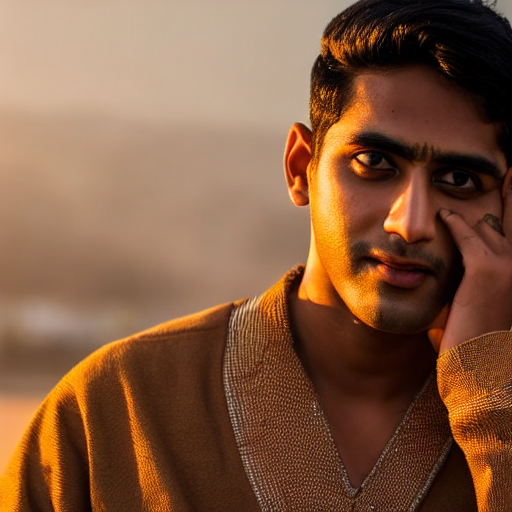

In [21]:
# WHY: Visual inspection is essential for evaluating generative output.
display(image)


## Cell 10 — Save result

In [22]:
# WHY: PNG preserves the generated result without JPEG compression.
output_path = "../outputs/notebook_generated.png"
image.save(output_path, format="PNG")
print("Saved:", output_path)


Saved: ../outputs/notebook_generated.png
